# Task 2: Exploratory Data Analysis (EDA)

## Forecasting Financial Inclusion in Ethiopia

### Week 11 Challenge

**Student:** Lalise Fufi

---

## Objective

The objective of this notebook is to explore Ethiopia's financial inclusion dataset, identify historical trends, understand relationships among indicators, investigate the influence of major events, assess data quality, and generate insights that will guide the forecasting models developed in later tasks.

1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

2. Load the Enriched Dataset

In [3]:
DATA = Path("../data/processed")

df = pd.read_csv(DATA / "ethiopia_fi_enriched.csv")

impact_links = pd.read_csv(
    DATA / "impact_links_enriched.csv"
)

reference = pd.read_csv(
    "../data/raw/reference_codes.csv"
)

In [4]:
print(df.shape)

print(impact_links.shape)

print(reference.shape)

(46, 34)
(15, 35)
(71, 4)


3. Dataset Overview

In [6]:
df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31 00:00:00,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31 00:00:00,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31 00:00:00,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            46 non-null     str    
 1   record_type          46 non-null     str    
 2   category             11 non-null     str    
 3   pillar               35 non-null     str    
 4   indicator            45 non-null     str    
 5   indicator_code       45 non-null     str    
 6   indicator_direction  35 non-null     str    
 7   value_numeric        35 non-null     float64
 8   value_text           11 non-null     str    
 9   value_type           46 non-null     str    
 10  unit                 35 non-null     str    
 11  observation_date     46 non-null     str    
 12  period_start         12 non-null     str    
 13  period_end           12 non-null     str    
 14  fiscal_year          46 non-null     str    
 15  gender               46 non-null     str    
 16  loc

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,46,46,REC_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
record_type,46,3,observation,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,11,7,policy,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pillar,35,4,ACCESS,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator,45,31,Account Ownership Rate,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,45,31,ACC_OWNERSHIP,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_direction,35,3,higher_better,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_numeric,35.0,NaN,NaN,NaN,88979858305.886566,411074453447.597595,1.08,21.0,56.0,13500000.0,2380000000000.0
value_text,11,4,Launched,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
value_type,46,8,percentage,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN


4. Dataset Summary

In [9]:
print("Shape:", df.shape)

print()

print(df["record_type"].value_counts())

print()

print(df["pillar"].value_counts(dropna=False))

print()

print(df["source_type"].value_counts(dropna=False))

Shape: (46, 34)

record_type
observation    32
event          11
target          3
Name: count, dtype: int64

pillar
ACCESS           17
USAGE            12
NaN              11
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

source_type
operator      16
survey        10
regulator      8
research       4
policy         4
calculated     2
news           2
Name: count, dtype: int64


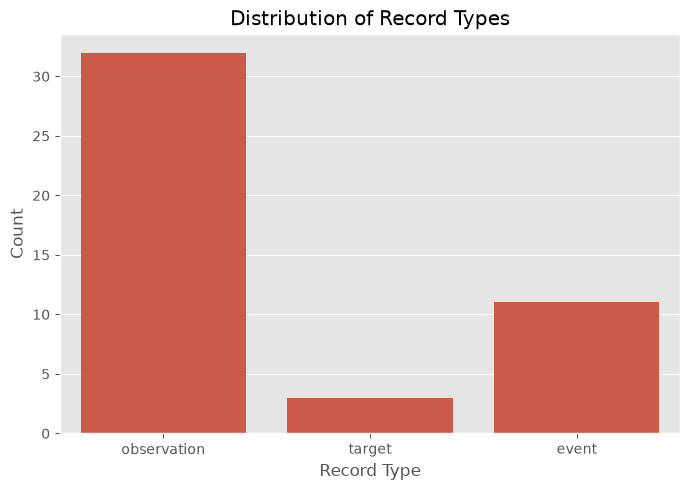

In [10]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="record_type"
)

plt.title("Distribution of Record Types")

plt.xlabel("Record Type")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

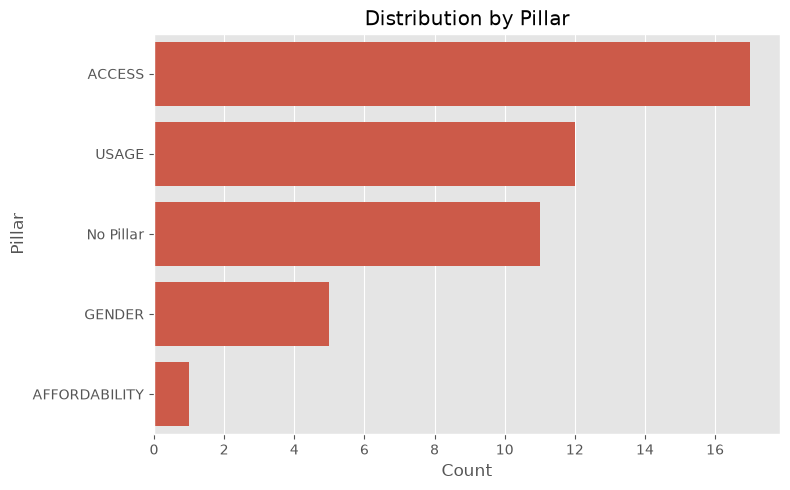

In [12]:
plt.figure(figsize=(8,5))

pillar_plot = df.copy()

pillar_plot["pillar"] = pillar_plot["pillar"].fillna("No Pillar")

sns.countplot(
    data=pillar_plot,
    y="pillar",
    order=pillar_plot["pillar"].value_counts().index
)

plt.title("Distribution by Pillar")

plt.xlabel("Count")

plt.ylabel("Pillar")

plt.tight_layout()

plt.show()

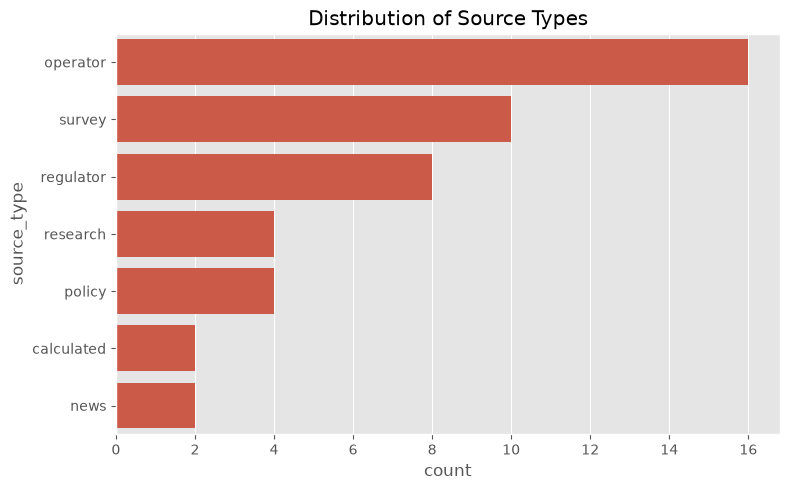

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y="source_type",
    order=df["source_type"].value_counts().index
)

plt.title("Distribution of Source Types")

plt.tight_layout()

plt.show()

### Interpretation

The enriched financial inclusion dataset contains **46 records** and **34 variables**, indicating that additional observations and events have been successfully incorporated while preserving the original unified schema. The dataset is dominated by **observation records (32)**, which provide the historical measurements used for trend analysis and forecasting. It also includes **11 event records** representing major policy changes, product launches, market developments, and infrastructure initiatives, together with **3 target records** that capture official financial inclusion goals.

The distribution across financial inclusion pillars shows that **ACCESS (17 records)** and **USAGE (12 records)** receive the greatest coverage, reflecting the primary forecasting objectives of this project. **GENDER (5 records)** and **AFFORDABILITY (1 record)** contain comparatively fewer observations, suggesting that demographic and affordability analyses are more limited. Additionally, **11 records have no assigned pillar**, corresponding to event records. This is expected because, according to the unified data schema, events are intentionally categorized by type (e.g., policy, product launch, infrastructure) rather than by financial inclusion pillar. Their effects on specific indicators are modeled separately through the **impact_link** table.

The source distribution indicates that the dataset relies primarily on **operator reports (16 records)** and **survey data (10 records)**, providing strong empirical evidence from organizations such as Ethio Telecom, Telebirr, M-Pesa, and the World Bank Global Findex. Regulatory publications contribute **8 records**, while **research studies (4)** and **policy documents (4)** provide supporting evidence. A smaller number of records originate from **calculated metrics (2)** and **news sources (2)**. This combination of official, operational, and research-based sources improves the reliability of the dataset while incorporating recent developments in Ethiopia's digital financial ecosystem.

Overall, the enriched dataset provides a balanced representation of financial inclusion indicators, supporting events, and multiple data sources. The additional observations strengthen the coverage of key Access and Usage indicators while maintaining consistency with the project's unified schema, making the dataset suitable for subsequent exploratory analysis, event impact modeling, and forecasting.

## Data Quality Assessment
5. Missing Values

In [14]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

impact_estimate        46
region                 46
related_indicator      46
relationship_type      46
evidence_basis         46
lag_months             46
impact_direction       46
impact_magnitude       46
notes                  43
category               35
value_text             35
period_end             34
period_start           34
collection_date        33
source_url             15
original_text          13
pillar                 11
indicator_direction    11
value_numeric          11
unit                   11
comparable_country      3
indicator               1
indicator_code          1
dtype: int64

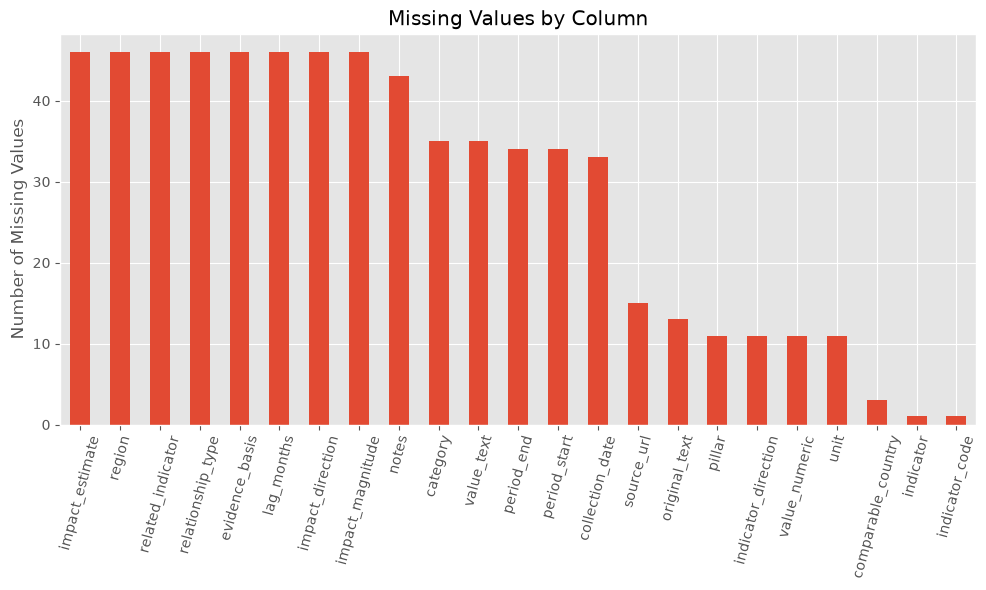

In [15]:
#Visualization
plt.figure(figsize=(10,6))

missing.plot(kind="bar")

plt.title("Missing Values by Column")

plt.ylabel("Number of Missing Values")

plt.xticks(rotation=75)

plt.tight_layout()

plt.show()

### Interpretation

The missing value analysis shows that the dataset contains a considerable number of null values; however, most of these are **expected and intentional** due to the unified schema that stores observations, events, targets, and impact links within a single table. Since different record types require different fields, many columns are naturally left blank for records where they are not applicable rather than indicating poor data quality.

Several impact-related fields, including **impact_estimate, related_indicator, relationship_type, evidence_basis, lag_months, impact_direction, and impact_magnitude**, contain missing values for all **46 records** in the main dataset because these attributes are stored separately in the **impact_links** table. Likewise, the **region** field is empty throughout the dataset since the available records represent national-level indicators rather than regional observations.

Other fields such as **category (35 missing)** and **value_text (35 missing)** are only applicable to specific record types. The **period_start** and **period_end** fields each contain **34 missing values**, reflecting that many observations represent single-date measurements rather than reporting periods. Metadata fields including **collection_date (33 missing)**, **source_url (15 missing)**, and **original_text (13 missing)** are partially populated because they were added mainly during the data enrichment process.

A small number of missing values appear in core analytical fields such as **pillar, indicator_direction, value_numeric, and unit (11 each)**. These correspond primarily to event records, which intentionally do not contain measurement values or pillar assignments. Only **one record** is missing an **indicator** and **indicator_code**, indicating that nearly all records are properly defined and identifiable.

Overall, the visualization confirms that the majority of missing values arise from the flexible design of the unified schema rather than incomplete data collection. The essential forecasting variables—including observation dates, record types, source information, and nearly all financial inclusion indicators—are well populated, making the dataset suitable for exploratory analysis, event impact modeling, and forecasting after filtering records by their respective record types.

6. Duplicate Records

In [16]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


7. Confidence Distribution

In [17]:
confidence = df["confidence"].value_counts()

confidence

confidence
high      42
medium     4
Name: count, dtype: int64

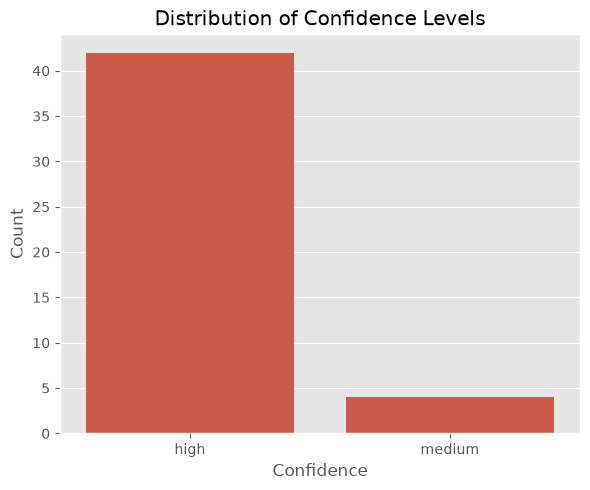

In [18]:
#Visualization
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="confidence",
    order=confidence.index
)

plt.title("Distribution of Confidence Levels")

plt.xlabel("Confidence")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

### Interpretation

The data quality assessment indicates that the enriched dataset contains **no duplicate records**, confirming that each entry represents a unique observation, event, or target. This demonstrates that the data integration and enrichment process maintained record uniqueness and avoided redundant information that could bias subsequent analyses or forecasting models.

The confidence assessment shows that the dataset is dominated by **high-confidence records (42)**, while only **4 records** are assigned **medium confidence**, and no records are classified as low confidence. This distribution reflects that most information originates from reliable sources such as official surveys, regulator reports, mobile network operators, and validated research publications. The few medium-confidence records generally represent estimated impacts or relationships inferred from comparable country evidence rather than directly observed measurements.

Overall, the absence of duplicate records together with the predominance of high-confidence data indicates that the dataset is of good quality and suitable for exploratory analysis, event impact modeling, and forecasting. Nevertheless, medium-confidence records should be interpreted with appropriate caution, particularly when drawing conclusions about estimated event impacts or forecasting future financial inclusion trends.

8. Temporal Coverage

In [19]:
#Convert dates
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

In [20]:
#Extract year
df["year"] = df["observation_date"].dt.year

In [21]:
#Coverage table
coverage = (
    df.groupby(["year","record_type"])
      .size()
      .unstack(fill_value=0)
)

coverage

record_type,event,observation,target
year,,,
2014.0,0,1,0
2017.0,0,1,0
2021.0,2,5,0
2022.0,1,0,0
2023.0,1,1,0
2024.0,3,11,0
2025.0,3,11,1
2028.0,0,0,1
2030.0,0,0,1


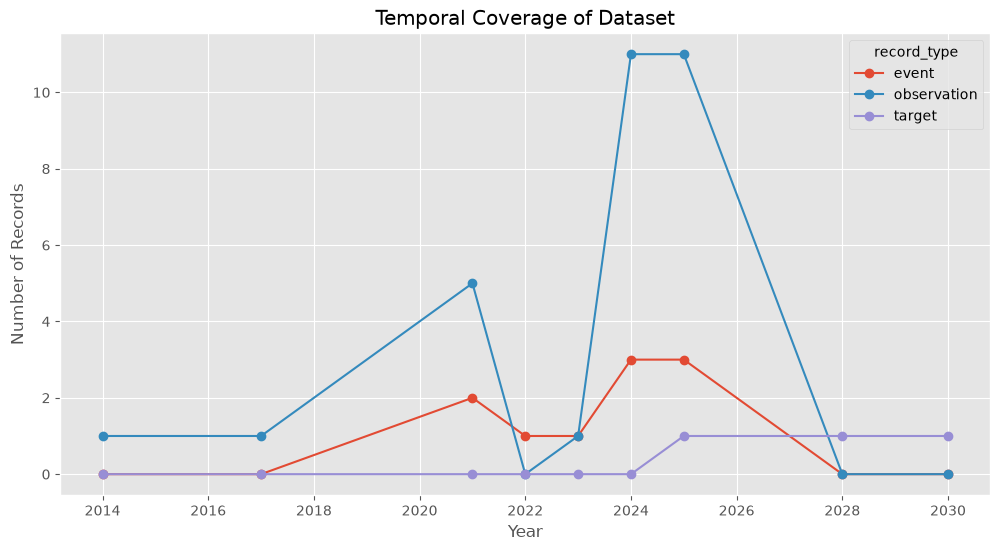

In [22]:
#Visualization
coverage.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Temporal Coverage of Dataset")

plt.xlabel("Year")

plt.ylabel("Number of Records")

plt.grid(True)

plt.show()

### Interpretation

The temporal coverage analysis shows that the dataset spans the period **2014 to 2030**, combining historical observations, significant financial inclusion events, and future policy targets. Observation records are concentrated between **2014 and 2025**, providing the historical evidence required for trend analysis and forecasting, while target records extend to **2028** and **2030**, representing Ethiopia's long-term financial inclusion objectives.

The earliest observations appear in **2014** and **2017**, corresponding to Global Findex survey years. Data coverage increases substantially from **2021 onward**, reflecting the rapid expansion of Ethiopia's digital financial ecosystem following major developments such as the launch of Telebirr, market liberalization, and increased digital payment adoption. The dataset contains **5 observations and 2 events in 2021**, followed by additional events in **2022** and **2023**. The highest concentration of records occurs in **2024** and **2025**, each containing **11 observation records**, with **3 event records** in both years. This indicates that the dataset emphasizes recent developments, making it well suited for forecasting near-term financial inclusion trends.

The visualization also highlights that event records are concentrated during periods of significant market and policy activity, allowing subsequent analyses to investigate how these interventions relate to changes in financial inclusion indicators. Meanwhile, the target records appearing in **2025**, **2028**, and **2030** provide benchmark goals against which future forecasts can be evaluated.

Overall, the temporal distribution demonstrates a logical progression from historical observations to recent policy interventions and future strategic targets. Although earlier years contain relatively few observations, the richer coverage from **2021–2025** provides a strong foundation for exploratory analysis, event impact assessment, and forecasting Ethiopia's Access and Usage indicators.

9. Indicator Coverage

In [23]:
#Observation records only
observations = df[
    df["record_type"]=="observation"
].copy()

In [24]:
#Coverage
indicator_coverage = (
    observations
    .groupby("indicator_code")
    .size()
    .sort_values(ascending=False)
)

indicator_coverage

indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_4G_COV            2
GEN_GAP_ACC           2
ACC_MM_ACCOUNT        2
USG_P2P_COUNT         2
ACC_BRANCH            1
ACC_MOBILE_PEN        1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
USG_ACTIVE_RATE       1
USG_ATM_COUNT         1
GEN_GAP_MOBILE        1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_MPESA_ACTIVE      1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_QR_PAY            1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

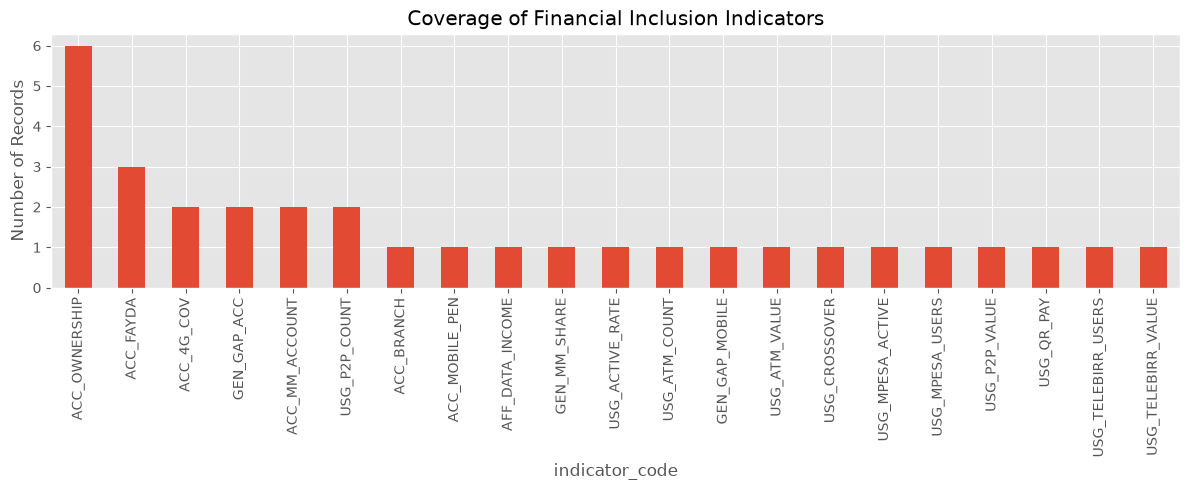

In [25]:
#Visualization
plt.figure(figsize=(12,5))

indicator_coverage.plot(kind="bar")

plt.ylabel("Number of Records")

plt.title("Coverage of Financial Inclusion Indicators")

plt.tight_layout()

plt.show()

In [26]:
#Sparse indicators
sparse = indicator_coverage[
    indicator_coverage <= 1
]

sparse

indicator_code
ACC_BRANCH            1
ACC_MOBILE_PEN        1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
USG_ACTIVE_RATE       1
USG_ATM_COUNT         1
GEN_GAP_MOBILE        1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_MPESA_ACTIVE      1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_QR_PAY            1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

### Interpretation

The indicator coverage analysis shows that the observation dataset contains **21 unique financial inclusion indicators**, providing a broad view of Ethiopia's digital financial ecosystem. However, the coverage is uneven across indicators, with a small number of core indicators being measured repeatedly while many supporting indicators have only a single observation.

The most frequently observed indicator is **Account Ownership (ACC_OWNERSHIP)** with **6 records**, reflecting its importance as the primary Access indicator in the Global Findex framework and the main forecasting target of this project. **Fayda Digital ID (ACC_FAYDA)** follows with **3 records**, highlighting the growing role of digital identity in expanding financial inclusion. Several indicators, including **4G Coverage (ACC_4G_COV)**, **Mobile Money Accounts (ACC_MM_ACCOUNT)**, **Gender Gap in Account Ownership (GEN_GAP_ACC)**, and **P2P Transactions (USG_P2P_COUNT)**, each have **2 observations**, providing sufficient information to examine recent trends.

In contrast, **15 indicators** have only **one recorded observation**, making them relatively sparse. These include infrastructure indicators such as **Bank Branches (ACC_BRANCH)** and **Mobile Penetration (ACC_MOBILE_PEN)**, affordability measures such as **AFF_DATA_INCOME**, gender-related indicators, transaction value metrics, QR payments, Telebirr and M-Pesa usage statistics, and other digital payment indicators. Although these variables may serve as valuable explanatory features for forecasting, their limited historical coverage restricts the application of traditional time series methods and requires cautious interpretation.

Overall, the visualization indicates that the dataset is strongest for the core Access indicator while many supporting indicators remain sparsely populated. These data gaps represent one of the primary limitations of the analysis and suggest that future work could benefit from incorporating additional historical observations from sources such as the World Bank Global Findex, National Bank of Ethiopia, GSMA, IMF Financial Access Survey, and operator reports to improve forecasting accuracy and strengthen event impact analysis.

## Data Quality Summary

The exploratory analysis indicates that the enriched financial inclusion dataset is generally well-structured and suitable for subsequent modeling and forecasting. Nevertheless, several characteristics of the unified schema should be considered during interpretation.

### Key Findings

- **Dataset Size:** The final enriched dataset contains **46 records** and **34 columns**, including **32 observations**, **11 events**, and **3 policy targets**.

- **No Duplicate Records:** Data quality checks confirmed that **no duplicate records** are present, indicating that each record represents a unique observation, event, or target.

- **High Confidence Data:** The majority of the dataset consists of highly reliable records, with **42 (91.3%)** records labeled as **High** confidence and only **4 (8.7%)** labeled as **Medium** confidence. No records were classified as Low confidence.

- **Missing Values Reflect the Unified Schema:** Several columns contain substantial missing values (e.g., `impact_estimate`, `related_indicator`, `lag_months`, `relationship_type`, `evidence_basis`, and `region`). These missing values are expected because different record types (observations, events, targets, and impact links) require different attributes. Therefore, the missing values are primarily structural rather than indicators of poor data quality.

- **Temporal Coverage:** The dataset spans the period from **2014 to 2030**. Historical observations are concentrated between **2014 and 2025**, while future policy targets extend to **2028** and **2030**. The richest coverage occurs during **2024** and **2025**, reflecting the inclusion of newly enriched indicators.

- **Indicator Coverage is Uneven:** A total of **21 financial inclusion indicators** are represented. While core indicators such as **Account Ownership (ACC_OWNERSHIP)** have multiple observations (6 records), many indicators—including QR payments, ATM usage, M-Pesa activity, Telebirr transactions, mobile penetration, and affordability—contain only a single observation. These sparse indicators provide useful contextual information but limit the application of advanced time-series forecasting techniques.

- **Balanced Data Sources:** The dataset integrates information from multiple sources, including mobile operators, surveys, regulators, policy documents, research publications, calculated indicators, and news reports. This diversity strengthens the overall analytical value of the dataset.

### Overall Assessment

Overall, the enriched dataset provides a reliable foundation for exploratory data analysis and event impact modeling. The absence of duplicate records, the predominance of high-confidence observations, and the incorporation of multiple trusted data sources enhance its credibility. However, the limited historical coverage for many indicators and the naturally sparse structure of the unified schema introduce uncertainty that should be acknowledged when interpreting results and developing forecasting models for Ethiopia's financial inclusion trends.